#### 선형회구와 경사하강법의 학습방법
모델의 최적화된 방법을 찾도록 도움을 주는 것    
기울기(가중치)와 절편을 이용해 최적화된 모델을 찾아 주는것 ==> 경사하강법 + 선형회귀    
SGD(Stochastic Gradient Descent)가 가중치와 절편을 이용해 오차(절대값, 제곱의 제곱근)를 줄여야 정답에 가까워짐    
경사하강법을 사용하지 않는다면 모든 경우의 수를 다 찾아야 한다.        

##### 선형회귀식의 가중치(w)와 절편(bias) => Y = wX + b
머신러닝/딥러닝의 학습이란? 데이터를 계속 업데이트 하면서 모델에 적용시키면서 오차가 가장 적은 기준(Y와 Y^ 비교)으로 가중치와 절편을 찾는것.     
규칙이란? 가중치와 절편을 계속 업데이틑 하는 것
규제란? 과대적합(train데이터는 정확도가 높으나 test데이터는 정확도가 낮음)을 방지하기 위해 가중치와 절편을 줄임.

#### 당뇨병 환자 데이터

In [3]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [5]:
# 데이터 크기 확인하기
print(diabetes.data.shape) # Feature
print(diabetes.target.shape) # target

(442, 10)
(442,)


In [6]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [7]:
# data의 일부보기(0~2번 Sample)
diabetes.data[0:2+1]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [8]:
diabetes.target[0:2+1]

array([151.,  75., 141.])

#### 당뇨병 환자 데이터의 시각화


In [9]:
import matplotlib.pyplot as plt

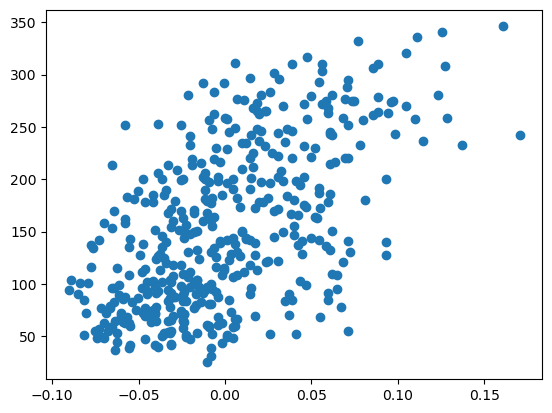

In [10]:
plt.scatter(
    diabetes.data[:,2],
    diabetes.target
)
plt.show()

In [12]:
# 상관계수 알아보기
import numpy as np

In [13]:
np.corrcoef(diabetes.data[:,2], diabetes.target)

array([[1.        , 0.58645013],
       [0.58645013, 1.        ]])

----
#### 경사하강법
: 경사하강법은 모델이 데이터를 잘 표현할 수 있도록 기울기(변화율)를 사용하여 모델을 조금씩 조정하는 최적화 알고리즘    

##### 예측값과 변화율
변화율 = 0 : 최적화된 모델(Y - Y^ = 0 ) => 변화율(기울기) = 0

##### 예측값(Y^)
예측값은 하나의 모델에서 수식의 결과로 나온 값을 의미
예측값이 정답값으로 수렴해야 한다.

#### 훈련데이터에서 잘 맞는 w와 b를 찾는 방법(Y = wX + b)
1. 무작위로 w와 b를 정한다.    
2. X에서 샘플 하나를 선택하여 Y^을 계산한다.    
3. Y^과 선택한 샘플의 진짜 Y를 비교한다. (예측값과 정답구하기 : 오차 구하기)    
4. Y^이 Y와 가까워지도록 w,b를 조정한다.(모델 조정하기 : 학습하기)    
5. 모든 샘플을 처리할떄 까지 2 ~ 4 항목을 반복한다.    

In [14]:
# 훈련 데이터의 Feature와 Target 정하기
x = diabetes.data[:,2]
y = diabetes.target

In [15]:
# 5개만 출력해보기
print(x[:5])
print(y[:5])

[ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]
[151.  75. 141. 206. 135.]


In [16]:
# w와 b를 초기화 하기 : 무작위로
w = 1
b = 1

In [17]:
# 훈련데이터의 첫번쨰 샘플로 y^ 계산하기
y_hat = x[0]*w + b
y_hat

np.float64(1.0616962065186832)

In [18]:
# Target과 예측데이터의 비교하기
print(y_hat)
print(y[0])

1.0616962065186832
151.0


> 당연한 결과지만 Target과 예측값이 너무 많은 차이가 발생

In [19]:
# w와 b를 조금씩 변경해서 y_hat이 증가하는지 감소하는지 살펴보기
# 기존 w에 0.1만 증가해보기
w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
y_hat_inc

np.float64(1.0678658271705517)

> y_hat 보다 y_hat_inc가 조금 더 Target에 근접해짐

In [20]:
# w값을 조정한 후 예측값 정도 확인하기
# w가 0.1 증가했을때 y_hat이 얼마나 증가했는지 계산해보기 (변화율 확인)
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

np.float64(0.06169620651868429)

In [21]:
# 0.1 -> 0.2
w_inc = w + 0.2
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

np.float64(0.06169620651868325)

> w_rate(변화율)이 x[0]의 값과 동일하다.

In [22]:
# 변화율을 확인했으니 다시 훈련데이터의 1번값으로 변화율을 구해보자
w=b=1
y_hat = x[0] * w + b
w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

np.float64(0.06169620651868429)

In [23]:
# 변화율로 가중치 업데이트 <- 학습하기
w_new = w + w_rate
w_new

np.float64(1.0616962065186843)

In [24]:
# 변화율로 절편 업데이트 <- 학습하기
b_inc = b + 0.1
y_hat_inc = w * x[0] + b_inc
y_hat_inc

np.float64(1.1616962065186833)

In [25]:
b_rate = (y_hat_inc - y_hat) / (b_inc - b)
b_rate

np.float64(1.0)

In [26]:
b_new = b + 1
b_new

2

#### 오차 역전파(backpropagation)
- 오차 역전파로 가중치와 절편을 업데이트 합니다. -> 손실함수(비용함수)를 구성한다.
- 오차 역전파는 y^과 y의 차이를 이용하여 w와 b를 업데이트
- 오차와 변화율을 곱하여 가중치 업데이트


In [27]:
err = y[0] - y_hat
w_new = w + w_rate * err
b_new = b + b_rate * err
print(w_new, b_new)

10.250624555903848 150.9383037934813


In [28]:
# 2번째 샘플 x[1]을 사용하여 오차를 구하고 새로운 w와 b를 구하기
y_hat = w_new * x[1] + b_new
err = y[1] - y_hat
w_rate = x[1] 
w_new = w_new + w_rate * err
b_new = b_new + 1 * err
print(w_new, b_new)

14.132317616380695 75.52764127612656


----

In [29]:
# 반복문을 통한 전체 샘플을 반복하기
w = b = 1
for x_i, y_i in zip(x, y):
    y_hat = x_i * w + b
    err = y_i - y_hat
    w_rate = x_i
    w = w + w_rate * err
    b = b + 1 * err
print(w, b)

587.8654539985616 99.4093556453094


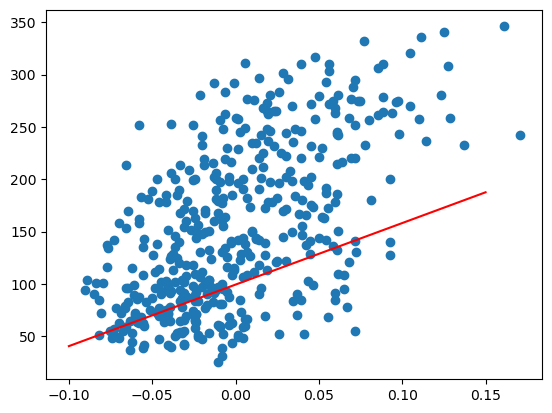

In [32]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)

plt.plot(
    [pt1[0], pt2[0]],
    [pt1[1], pt2[1]],
    'r'
)
plt.show()

#### Epoch로 반복하기

In [33]:
# Epoch를 통한 반복하기

w = b = 1
for _ in range(300):
    for x_i, y_i in zip(x, y):
        y_hat = x_i * w + b
        err = y_i - y_hat
        w_rate = x_i
        w = w + w_rate * err
        b = b + 1 * err
print(w, b)

913.5973364346786 123.39414383177173


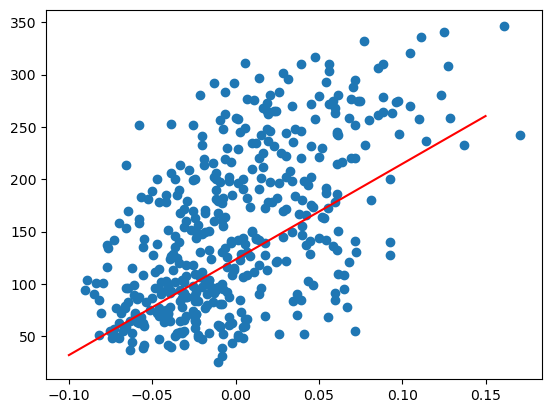

In [36]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)

plt.plot(
    [pt1[0], pt2[0]],
    [pt1[1], pt2[1]],
    'r'
)
plt.show()

> Y^ = 913.6 *X + 123.4

In [43]:
# 모델로 예측해보기
x_new = 0.18
y_pred = x_new * w + b
y_pred

np.float64(287.8416643900139)

In [40]:
fruits = ['apple', 'banana', 'cherry']
prices = [1000, 2000, 3000]

for index, (fruit, price) in enumerate(zip(fruits, prices)):
    print(f"Index {index}: {fruit}, {price} won")

Index 0: apple, 1000 won
Index 1: banana, 2000 won
Index 2: cherry, 3000 won


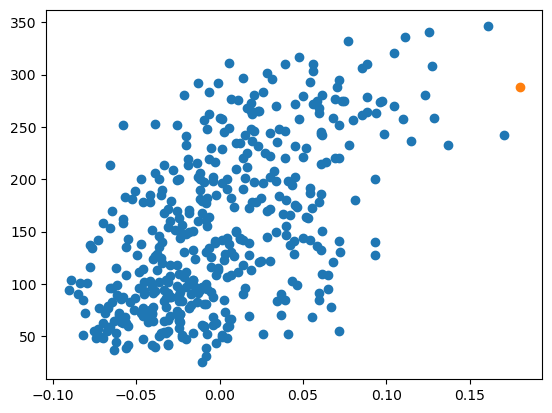

In [44]:
plt.scatter(x, y)
plt.scatter(x_new, y_pred)

plt.show()

---
#### 모델 만들기 정리
1. w와 b를 임의의 값(1, 1)로 초기화 하고 훈련데이터의 샘플을 하니씩 대입하여 Y와 Y^의 오차를 구한다.    
2. 1에서 구한 오차를 w와 b의 변화율에 곱하고 이를 이용하여 w와 b를 업데이트 한다(학습)     
3. 만약 Y^이 Y보다 커지는 오차는 음수가 되오 자동으로 w와 b가 줄어드는 방향으로 업데이트 된다.     
4. 반대로 Y^이 Y보다 작으면 오차는 양수가 되어 w와 b가 더 커지도록 업데이트 한다.        

#### 선형회귀를 위한 class 만들기

In [45]:
class LRModel:
    # Property
    # constructor
    def __init__(self):
        self.w = 1.0
        self.b = 1.0

    # method
    # 정방향 계산
    def forpass(self, x):
        y_hat = x * self.w + self.b # 직선 방정식
        return y_hat
    
    # 역방향 계산(오차율 들어감)
    def backprop(self, x, err):
        w_grad = x * err # 가중치에 대한 그래디언트
        b_grad = 1 * err # 절편에 대한 그레디언트를 계산
        return w_grad, b_grad

    # 훈련
    def fit(self, x, y, epoch):
        for _ in range(epoch):
            for x_i, y_i in zip(x, y):
                y_hat = self.forpass(x_i)
                err = y_i - y_hat
                w_grad, b_grad = self.backprop(x_i, err)
                self.w += w_grad
                self.b += b_grad
        return self.w, self.b


In [50]:
lrmodel = LRModel()
w, b = lrmodel.fit(x, y, 200)
print(w, b)

913.5973364346786 123.39414383177173


----
#### 선형회귀
선형방정식을 사용하여 연속적인 값을 예측하는 알고리즘으로 데이터를 가장 잘 표현하는 방정식의 계수를 구할 수 있습니다.      
머신러닝 알고리즘이지만 딥러닝에서 사용하는 인공신경망 알고리즘의 기초가 됩니다.    
선형회귀 -> Logistic Regression -> 인공신경망 -> Deep Learning